# 07 — Live Demo: Dense vs Sparse Encoding

Type **any query** and instantly see:
- 🟦 The **dense vector** — 1024 numbers, all non-zero, meaning packed in geometry
- 🟧 The **sparse vector** — which exact terms fired and how much
- 🔍 **Top-3 results** from each method side by side
- 🏆 **Winner** for that query type

```python
demo("your query here")   # ← change this to anything
```

## Step 1 — Install & Import

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
    'boto3', 'qdrant-client', 'scikit-learn', 'numpy', 'matplotlib', 'python-dotenv'])
print('Ready.')

Ready.


In [2]:
from dotenv import load_dotenv
load_dotenv('../../../.env')

import os, json, time, uuid
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import boto3
from sklearn.feature_extraction.text import TfidfVectorizer
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct,
    SparseVector, SparseVectorParams, SparseIndexParams
)

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27', 'axes.edgecolor': '#3a3d4d',
    'axes.labelcolor': '#e0e0e0', 'xtick.color': '#a0a0b0',
    'ytick.color': '#a0a0b0', 'text.color': '#e0e0e0',
    'grid.color': '#2a2d3d', 'grid.linestyle': '--', 'grid.alpha': 0.4,
})
print('Imports OK')

Imports OK


## Step 2 — Connect to Bedrock + Qdrant

In [3]:
AWS_REGION  = os.getenv('AWS_DEFAULT_REGION', 'us-east-1')
EMBED_MODEL = 'amazon.titan-embed-text-v2:0'
DIM         = 1024

bedrock = boto3.client('bedrock-runtime', region_name=AWS_REGION)

def embed(text: str) -> np.ndarray:
    body = json.dumps({'inputText': text, 'dimensions': DIM, 'normalize': True})
    resp = bedrock.invoke_model(
        modelId=EMBED_MODEL, body=body,
        contentType='application/json', accept='application/json'
    )
    return np.array(json.loads(resp['body'].read())['embedding'], dtype=np.float32)

QDRANT_URL = os.getenv('QDRANT_URL', '')
QDRANT_KEY = os.getenv('QDRANT_API_KEY', '')
if QDRANT_URL:
    kw = {'url': QDRANT_URL}
    if QDRANT_KEY: kw['api_key'] = QDRANT_KEY
    qc = QdrantClient(**kw)
    print(f'Qdrant Cloud: {QDRANT_URL}')
else:
    qc = QdrantClient(':memory:')
    print('Qdrant in-memory')

v = embed('hello')
print(f'Embedding OK — dim={v.shape[0]}, norm={np.linalg.norm(v):.4f}')

Qdrant in-memory


Embedding OK — dim=1024, norm=1.0000


## Step 3 — Corpus

40 sentences across 8 topics — chosen to expose **exactly** where dense beats sparse and vice versa.

In [4]:
corpus = [
    # ── Technology ────────────────────────────────────────────────────────────
    ("Gradient descent optimises neural network weights.",        "Technology"),
    ("Transformers use self-attention to model sequences.",       "Technology"),
    ("Backpropagation computes gradients for weight updates.",    "Technology"),
    ("Overfitting occurs when a model memorises training data.",  "Technology"),
    ("Convolutional networks excel at image recognition tasks.",  "Technology"),

    # ── AWS / Cloud (codes & product names — sparse territory) ────────────────
    ("AWS S3 stores objects in buckets with IAM policies.",       "AWS"),
    ("EC2 instances run virtual machines in the cloud.",          "AWS"),
    ("Lambda functions execute serverless code on AWS.",          "AWS"),
    ("DynamoDB is a fully managed NoSQL database service.",       "AWS"),
    ("CloudWatch monitors metrics and logs for AWS resources.",   "AWS"),

    # ── Animals ───────────────────────────────────────────────────────────────
    ("The dog chased the cat around the garden.",                 "Animals"),
    ("Dolphins communicate using echolocation and clicks.",       "Animals"),
    ("Elephants have strong social bonds within their herds.",    "Animals"),
    ("The eagle soared high above the mountain peaks.",           "Animals"),
    ("Wolves hunt in coordinated packs across open terrain.",     "Animals"),

    # ── Space ─────────────────────────────────────────────────────────────────
    ("The Milky Way is a spiral galaxy containing billions of stars.", "Space"),
    ("Black holes bend spacetime with extreme gravitational force.",    "Space"),
    ("NASA launched the James Webb Space Telescope in 2021.",           "Space"),
    ("Neutron stars are incredibly dense stellar remnants.",            "Space"),
    ("Mars has two small moons called Phobos and Deimos.",              "Space"),

    # ── Health ────────────────────────────────────────────────────────────────
    ("Vaccines train the immune system to fight pathogens.",      "Health"),
    ("Regular exercise reduces the risk of heart disease.",       "Health"),
    ("Antibiotics kill bacteria but are ineffective against viruses.", "Health"),
    ("The gut microbiome influences both mental and physical health.",  "Health"),
    ("Sleep deprivation impairs memory consolidation and focus.",       "Health"),

    # ── Finance ───────────────────────────────────────────────────────────────
    ("Inflation erodes the purchasing power of money over time.",  "Finance"),
    ("Compound interest grows wealth exponentially over decades.", "Finance"),
    ("Diversification reduces risk across an investment portfolio.","Finance"),
    ("Central banks raise interest rates to cool down inflation.", "Finance"),
    ("GDP measures the total economic output of a country.",       "Finance"),

    # ── Food ──────────────────────────────────────────────────────────────────
    ("Pasta is best cooked al dente in salted boiling water.",    "Food"),
    ("Fermentation is used to make bread, beer, and yoghurt.",    "Food"),
    ("Umami is considered the fifth fundamental taste.",           "Food"),
    ("Sauteing garlic in olive oil creates aromatic depth.",      "Food"),
    ("Fresh herbs and citrus brighten heavy, rich dishes.",       "Food"),

    # ── History ───────────────────────────────────────────────────────────────
    ("The Roman Empire fell in 476 AD after centuries of decline.", "History"),
    ("The printing press revolutionised the spread of knowledge.",  "History"),
    ("World War II ended in 1945 after the surrender of Germany.",  "History"),
    ("The Industrial Revolution transformed manufacturing globally.","History"),
    ("The moon landing in 1969 was a milestone for humanity.",       "History"),
]

sentences = [c[0] for c in corpus]
topics    = [c[1] for c in corpus]
print(f'Corpus: {len(corpus)} sentences across {len(set(topics))} topics')

Corpus: 40 sentences across 8 topics


## Step 4 — Build Dense Index (Bedrock Titan V2)

In [5]:
print('Embedding corpus with Bedrock Titan V2...')
dense_vecs = []
for i, s in enumerate(sentences):
    dense_vecs.append(embed(s))
    time.sleep(0.05)
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{len(sentences)}')
dense_matrix = np.vstack(dense_vecs)   # (40, 1024)

DCOLL = 'live_demo_dense'
for c in qc.get_collections().collections:
    if c.name == DCOLL: qc.delete_collection(DCOLL)
qc.create_collection(DCOLL, vectors_config=VectorParams(size=DIM, distance=Distance.COSINE))
qc.upsert(DCOLL, points=[
    PointStruct(id=i, vector=dense_matrix[i].tolist(),
                payload={'text': sentences[i], 'topic': topics[i]})
    for i in range(len(sentences))
])
print(f'Dense index ready — {len(sentences)} docs, {DIM} dims')

Embedding corpus with Bedrock Titan V2...


  10/40


  20/40


  30/40


  40/40
Dense index ready — 40 docs, 1024 dims


## Step 5 — Build Sparse Index (TF-IDF)

In [6]:
VOCAB = 1000
tfidf = TfidfVectorizer(max_features=VOCAB, ngram_range=(1, 2), sublinear_tf=True)
sparse_csr = tfidf.fit_transform(sentences)   # (40, 1000)
feat_names = tfidf.get_feature_names_out()

sparsity = (1 - sparse_csr.nnz / (sparse_csr.shape[0] * sparse_csr.shape[1])) * 100
print(f'TF-IDF: vocab={VOCAB}, sparsity={sparsity:.1f}%, avg {sparse_csr.nnz/len(sentences):.1f} terms/doc')

SCOLL = 'live_demo_sparse'
for c in qc.get_collections().collections:
    if c.name == SCOLL: qc.delete_collection(SCOLL)
qc.create_collection(SCOLL, vectors_config={},
    sparse_vectors_config={'sparse': SparseVectorParams(index=SparseIndexParams(on_disk=False))})

sp_points = []
for i in range(len(sentences)):
    row = sparse_csr[i]
    sp_points.append(PointStruct(
        id=i,
        vector={'sparse': SparseVector(indices=row.nonzero()[1].tolist(), values=row.data.tolist())},
        payload={'text': sentences[i], 'topic': topics[i]}
    ))
qc.upsert(SCOLL, points=sp_points)
print(f'Sparse index ready — {len(sentences)} docs, {VOCAB} dims')

TF-IDF: vocab=1000, sparsity=97.2%, avg 14.9 terms/doc
Sparse index ready — 40 docs, 1000 dims


## Step 6 — The `demo()` Function

Call `demo("any query")` to see exactly what each method does.

In [7]:
def demo(query: str, top_k: int = 3):
    """Show dense vs sparse vectors and results for any query."""

    # ── 1. Encode query ──────────────────────────────────────────────────────
    q_dense  = embed(query)
    q_sparse = tfidf.transform([query])
    sp_idx   = q_sparse.nonzero()[1].tolist()
    sp_vals  = q_sparse.data.tolist()

    # ── 2. Search ─────────────────────────────────────────────────────────────
    d_hits = qc.query_points(DCOLL, query=q_dense.tolist(),
                              limit=top_k, with_payload=True).points
    if sp_idx:
        s_hits = qc.query_points(SCOLL,
                     query=SparseVector(indices=sp_idx, values=sp_vals),
                     using='sparse', limit=top_k, with_payload=True).points
    else:
        s_hits = []

    # ── 3. Figure layout ──────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 14), facecolor='#0f1117')
    gs  = gridspec.GridSpec(3, 2, hspace=0.55, wspace=0.35,
                            height_ratios=[0.08, 1, 1])

    # ── Title banner ──────────────────────────────────────────────────────────
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis('off')
    ax_title.text(0.5, 0.5, f'Query: "{query}"',
                  ha='center', va='center', fontsize=14,
                  color='#FFD54F', fontweight='bold',
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='#2a2d3d', edgecolor='#FFD54F', alpha=0.8))

    # ── Plot A: Dense vector (first 80 dims) ──────────────────────────────────
    ax_a = fig.add_subplot(gs[1, 0])
    ax_a.set_facecolor('#1a1d27')
    show = 80
    dims = np.arange(show)
    vals = q_dense[:show]
    colors_d = ['#00BCD4' if v > 0 else '#EF5350' for v in vals]
    ax_a.bar(dims, vals, color=colors_d, alpha=0.85, width=1.0)
    ax_a.axhline(0, color='white', linewidth=0.5, alpha=0.4)
    ax_a.set_xlabel(f'Dimension index (showing first {show} of {DIM})')
    ax_a.set_ylabel('Value')
    ax_a.set_title(
        f'🟦  DENSE VECTOR (Bedrock Titan V2)\n'
        f'ALL {DIM} dims non-zero — {(np.abs(q_dense) > 1e-4).sum()} active '
        f'({(np.abs(q_dense) > 1e-4).mean()*100:.0f}%)\n'
        f'min={q_dense.min():.3f}  max={q_dense.max():.3f}  '
        f'norm={np.linalg.norm(q_dense):.4f}',
        color='#00BCD4', fontsize=9, pad=6)
    ax_a.grid(axis='y', alpha=0.3)

    # ── Plot B: Sparse vector (non-zero terms only) ───────────────────────────
    ax_b = fig.add_subplot(gs[1, 1])
    ax_b.set_facecolor('#1a1d27')
    if sp_idx:
        order  = np.argsort(sp_vals)[::-1][:20]
        terms  = [feat_names[sp_idx[o]] for o in order]
        wts    = [sp_vals[o] for o in order]
        ax_b.barh(range(len(terms)), wts, color='#FF6D00', alpha=0.85,
                  edgecolor='white', linewidth=0.3)
        ax_b.set_yticks(range(len(terms)))
        ax_b.set_yticklabels(terms, fontsize=9)
        ax_b.invert_yaxis()
        ax_b.set_xlabel('TF-IDF weight')
        zero_count = VOCAB - len(sp_idx)
        ax_b.set_title(
            f'🟧  SPARSE VECTOR (TF-IDF)\n'
            f'Only {len(sp_idx)} of {VOCAB} dims fire '
            f'({len(sp_idx)/VOCAB*100:.1f}% non-zero)\n'
            f'{zero_count} dims = 0 (not shown)',
            color='#FF6D00', fontsize=9, pad=6)
        ax_b.grid(axis='x', alpha=0.3)
    else:
        ax_b.text(0.5, 0.5, 'No vocab overlap!\n(0 terms matched)\n\nSparse returns nothing.',
                  ha='center', va='center', fontsize=13, color='#EF5350',
                  transform=ax_b.transAxes)
        ax_b.set_title('🟧  SPARSE VECTOR — ZERO MATCH\n(query words not in vocabulary)',
                       color='#FF6D00', fontsize=9, pad=6)

    # ── Plot C: Dense results ─────────────────────────────────────────────────
    ax_c = fig.add_subplot(gs[2, 0])
    ax_c.set_facecolor('#1a1d27')
    ax_c.axis('off')
    header = 'Rank   Score    Topic          Result text'
    lines  = [header, '─' * 72]
    for rank, h in enumerate(d_hits, 1):
        txt   = h.payload['text']
        topic = h.payload['topic']
        score = h.score
        trunc = (txt[:55] + '…') if len(txt) > 55 else txt
        lines.append(f'  #{rank}    {score:.3f}   {topic:<14}  {trunc}')
    ax_c.text(0.02, 0.95, '\n'.join(lines),
              transform=ax_c.transAxes, va='top', ha='left',
              fontsize=8.5, fontfamily='monospace', color='#e0e0e0',
              bbox=dict(boxstyle='round', facecolor='#12263a', alpha=0.7))
    ax_c.set_title('🟦  Dense Top Results\n(finds meaning, not just words)',
                   color='#00BCD4', fontsize=10, pad=6)

    # ── Plot D: Sparse results ────────────────────────────────────────────────
    ax_d = fig.add_subplot(gs[2, 1])
    ax_d.set_facecolor('#1a1d27')
    ax_d.axis('off')
    if s_hits:
        lines2 = [header, '─' * 72]
        for rank, h in enumerate(s_hits, 1):
            txt   = h.payload['text']
            topic = h.payload['topic']
            score = h.score
            trunc = (txt[:55] + '…') if len(txt) > 55 else txt
            lines2.append(f'  #{rank}    {score:.3f}   {topic:<14}  {trunc}')
        ax_d.text(0.02, 0.95, '\n'.join(lines2),
                  transform=ax_d.transAxes, va='top', ha='left',
                  fontsize=8.5, fontfamily='monospace', color='#e0e0e0',
                  bbox=dict(boxstyle='round', facecolor='#2a1a0a', alpha=0.7))
    else:
        ax_d.text(0.5, 0.5, 'No results — sparse returned nothing\nbecause query words are not in the vocabulary.',
                  ha='center', va='center', fontsize=11, color='#EF5350',
                  transform=ax_d.transAxes)
    ax_d.set_title('🟧  Sparse Top Results\n(finds exact keywords only)',
                   color='#FF6D00', fontsize=10, pad=6)

    plt.suptitle('Dense vs Sparse — Live Vector Inspection',
                 fontsize=13, color='#e0e0e0', y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Console summary ───────────────────────────────────────────────────────
    print(f'\n{"─"*70}')
    print(f'Query        : "{query}"')
    print(f'Dense vector : {DIM} dims, ALL non-zero ({(np.abs(q_dense)>1e-4).sum()} > 1e-4)')
    print(f'Sparse vector: {VOCAB} dims, only {len(sp_idx)} non-zero '
          f'({len(sp_idx)/VOCAB*100:.1f}%)')
    if sp_idx:
        top3_terms = sorted(zip([feat_names[i] for i in sp_idx], sp_vals),
                            key=lambda x: -x[1])[:3]
        print(f'Top sparse terms : {", ".join(f"{t}({v:.2f})" for t,v in top3_terms)}')
    print(f'Dense  #1 : "{d_hits[0].payload["text"][:65]}"  (score={d_hits[0].score:.3f})')
    if s_hits:
        print(f'Sparse #1 : "{s_hits[0].payload["text"][:65]}"  (score={s_hits[0].score:.3f})')
    else:
        print(f'Sparse #1 : NO RESULT (query words not in vocabulary)')
    d_topic = d_hits[0].payload['topic'] if d_hits else 'None'
    s_topic = s_hits[0].payload['topic'] if s_hits else 'None'
    same = '✅ AGREE' if d_topic == s_topic else '⚔️  DISAGREE'
    print(f'Verdict      : {same} — Dense→{d_topic}  Sparse→{s_topic}')
    print(f'{"─"*70}\n')

print('demo() ready — call demo("your query") in any cell below')

demo() ready — call demo("your query") in any cell below


---
## Step 7 — Live Examples

### 7a — Paraphrase: Dense wins, Sparse fails
> Query uses **synonyms** — no shared words with corpus.
> Dense finds meaning. Sparse finds nothing.

/tmp/ipykernel_313775/2401388543.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/participant/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/participant/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128999 (\N{LARGE ORANGE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


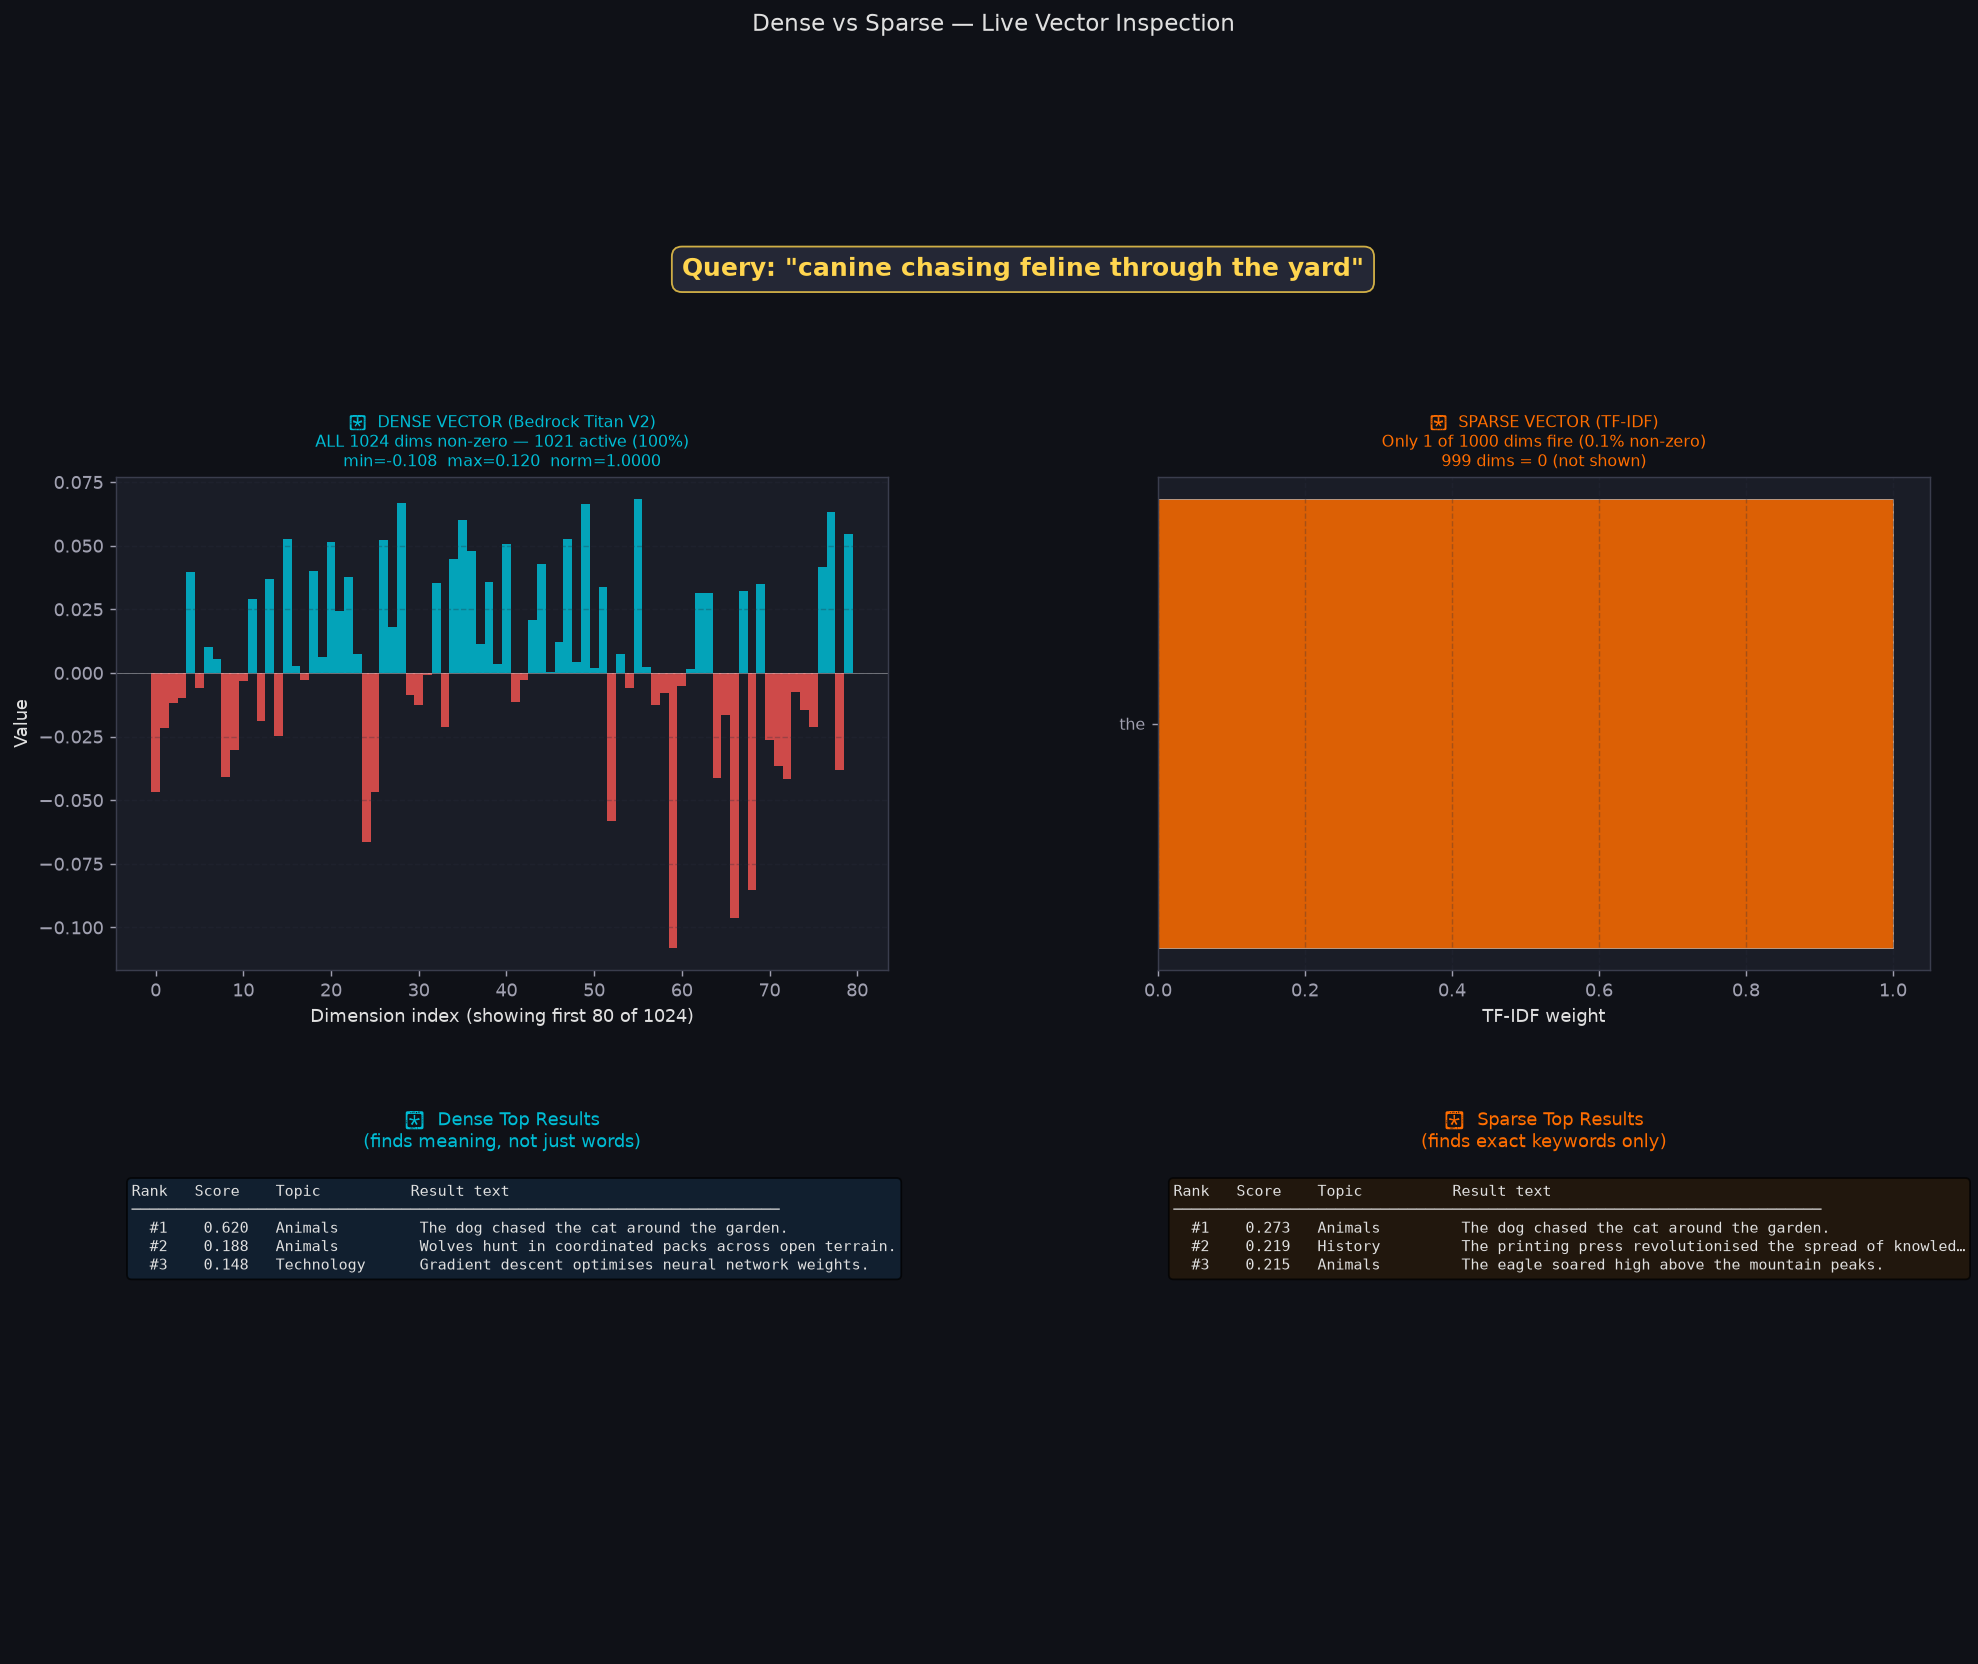


──────────────────────────────────────────────────────────────────────
Query        : "canine chasing feline through the yard"
Dense vector : 1024 dims, ALL non-zero (1021 > 1e-4)
Sparse vector: 1000 dims, only 1 non-zero (0.1%)
Top sparse terms : the(1.00)
Dense  #1 : "The dog chased the cat around the garden."  (score=0.620)
Sparse #1 : "The dog chased the cat around the garden."  (score=0.273)
Verdict      : ✅ AGREE — Dense→Animals  Sparse→Animals
──────────────────────────────────────────────────────────────────────



In [8]:
demo("canine chasing feline through the yard")

### 7b — Paraphrase: Dense wins again
> "weight optimization algorithm" → means gradient descent, but shares zero words.

/tmp/ipykernel_313775/2401388543.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/participant/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/participant/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128999 (\N{LARGE ORANGE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


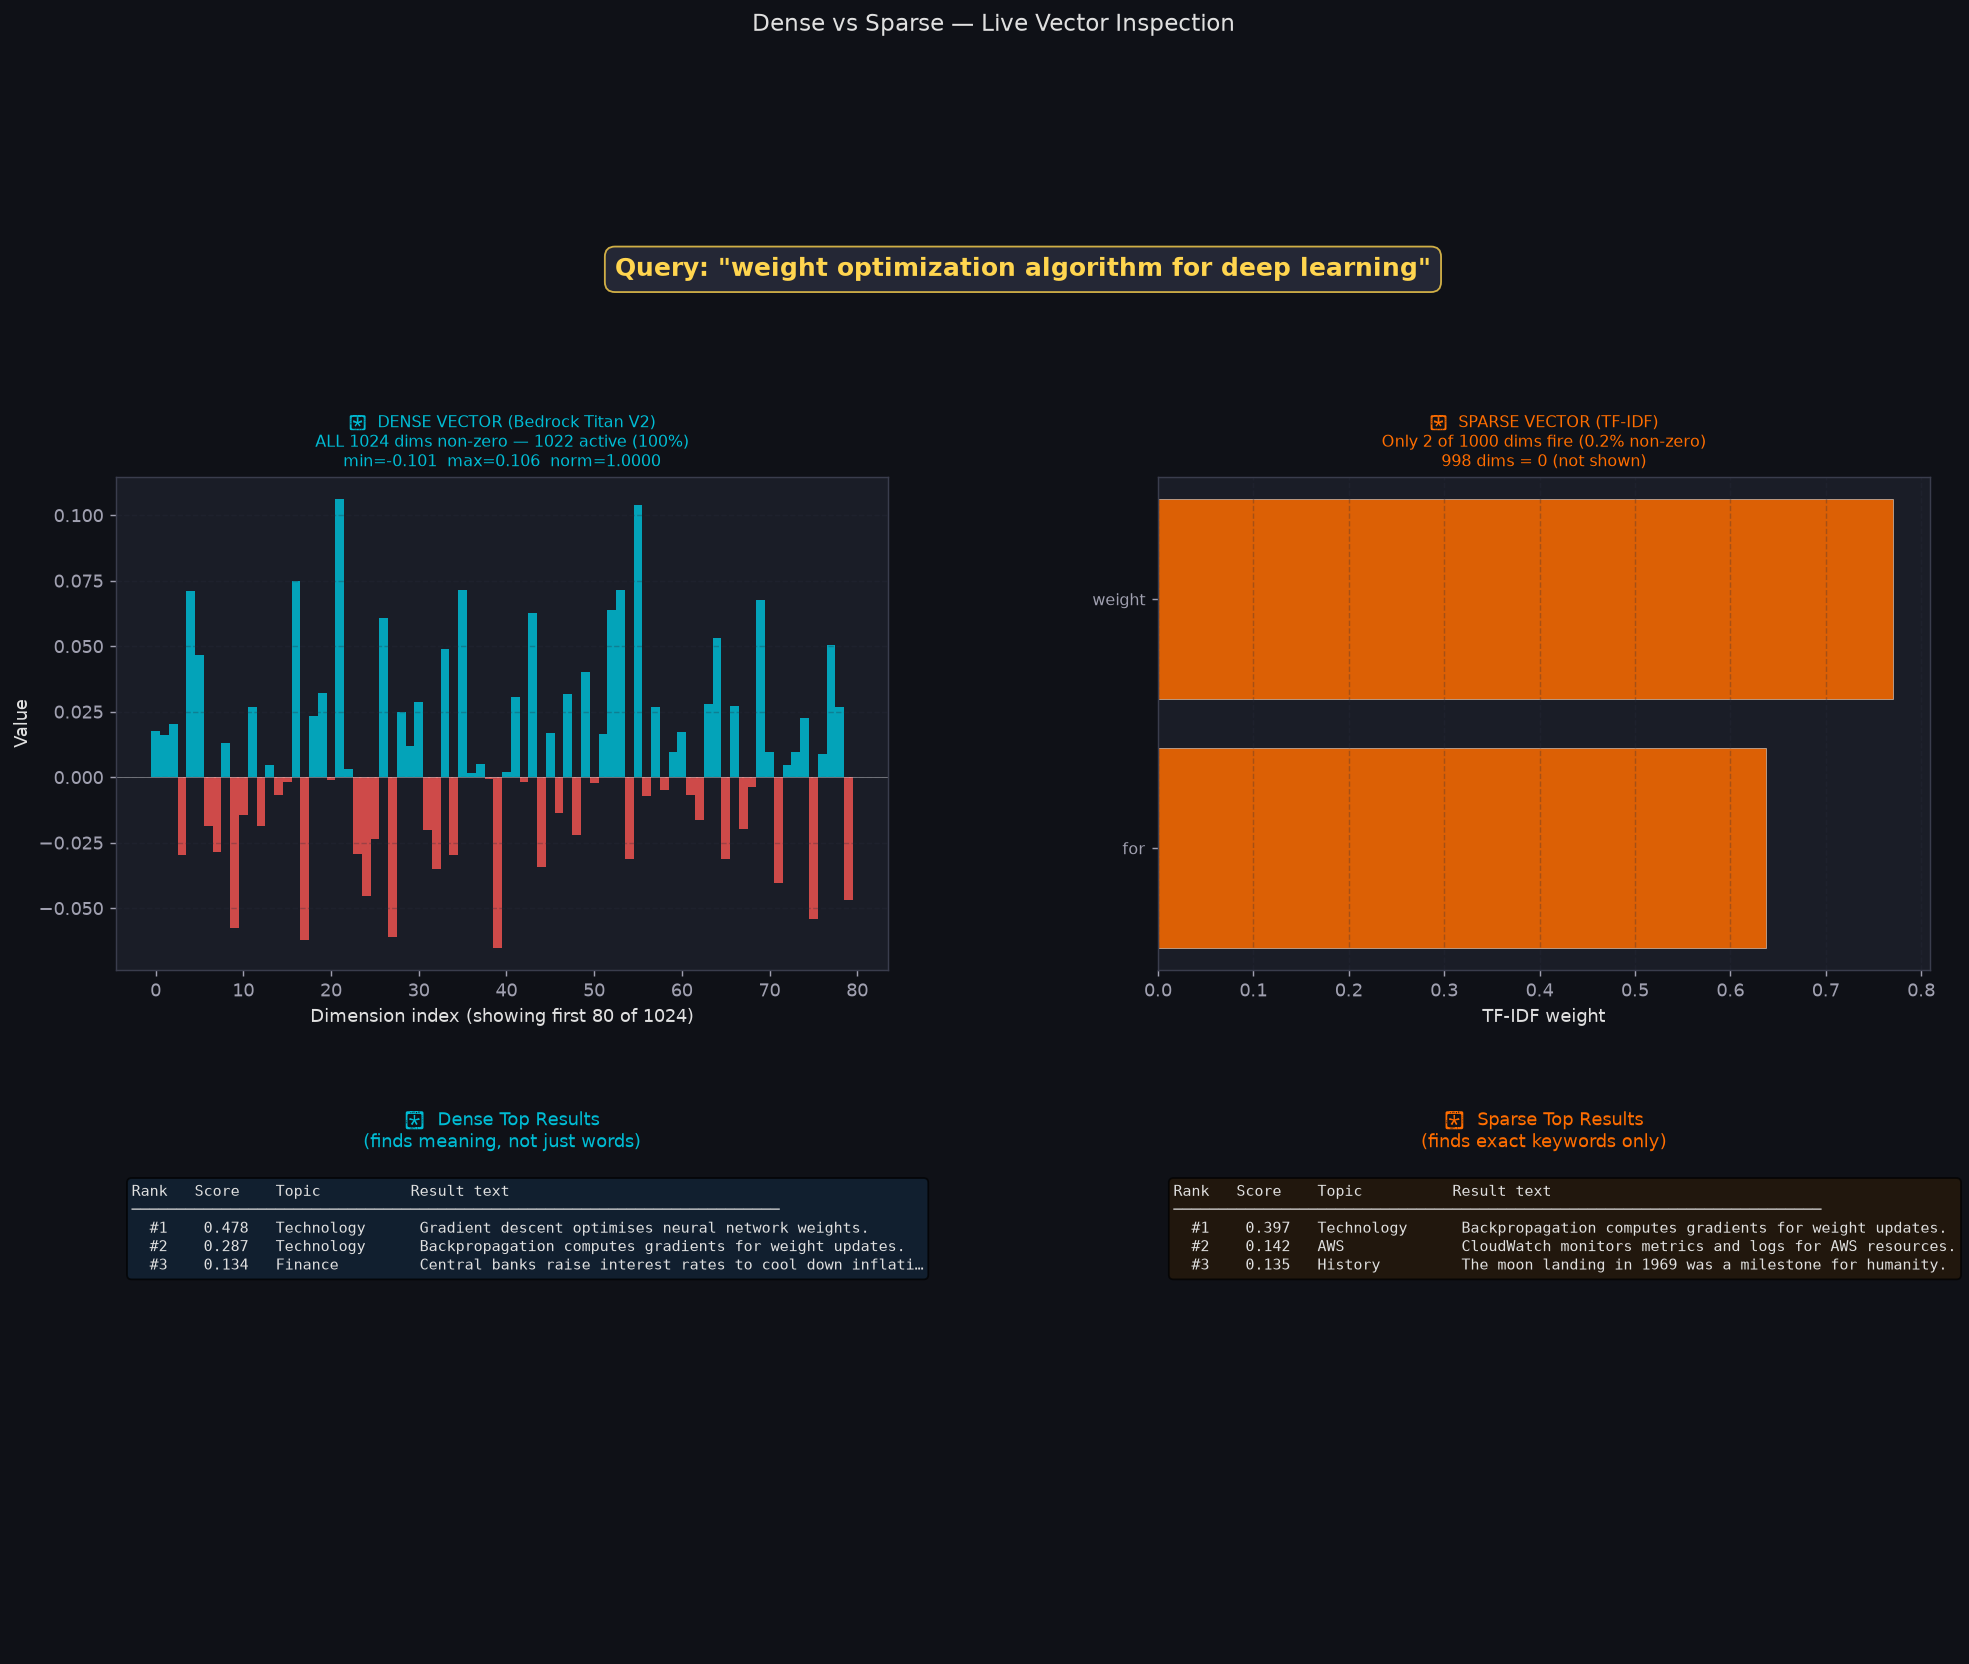


──────────────────────────────────────────────────────────────────────
Query        : "weight optimization algorithm for deep learning"
Dense vector : 1024 dims, ALL non-zero (1022 > 1e-4)
Sparse vector: 1000 dims, only 2 non-zero (0.2%)
Top sparse terms : weight(0.77), for(0.64)
Dense  #1 : "Gradient descent optimises neural network weights."  (score=0.478)
Sparse #1 : "Backpropagation computes gradients for weight updates."  (score=0.397)
Verdict      : ✅ AGREE — Dense→Technology  Sparse→Technology
──────────────────────────────────────────────────────────────────────



In [9]:
demo("weight optimization algorithm for deep learning")

### 7c — Exact keywords: Sparse wins
> Product codes and proper nouns — sparse matches exactly.

/tmp/ipykernel_313775/2401388543.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/participant/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/participant/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128999 (\N{LARGE ORANGE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


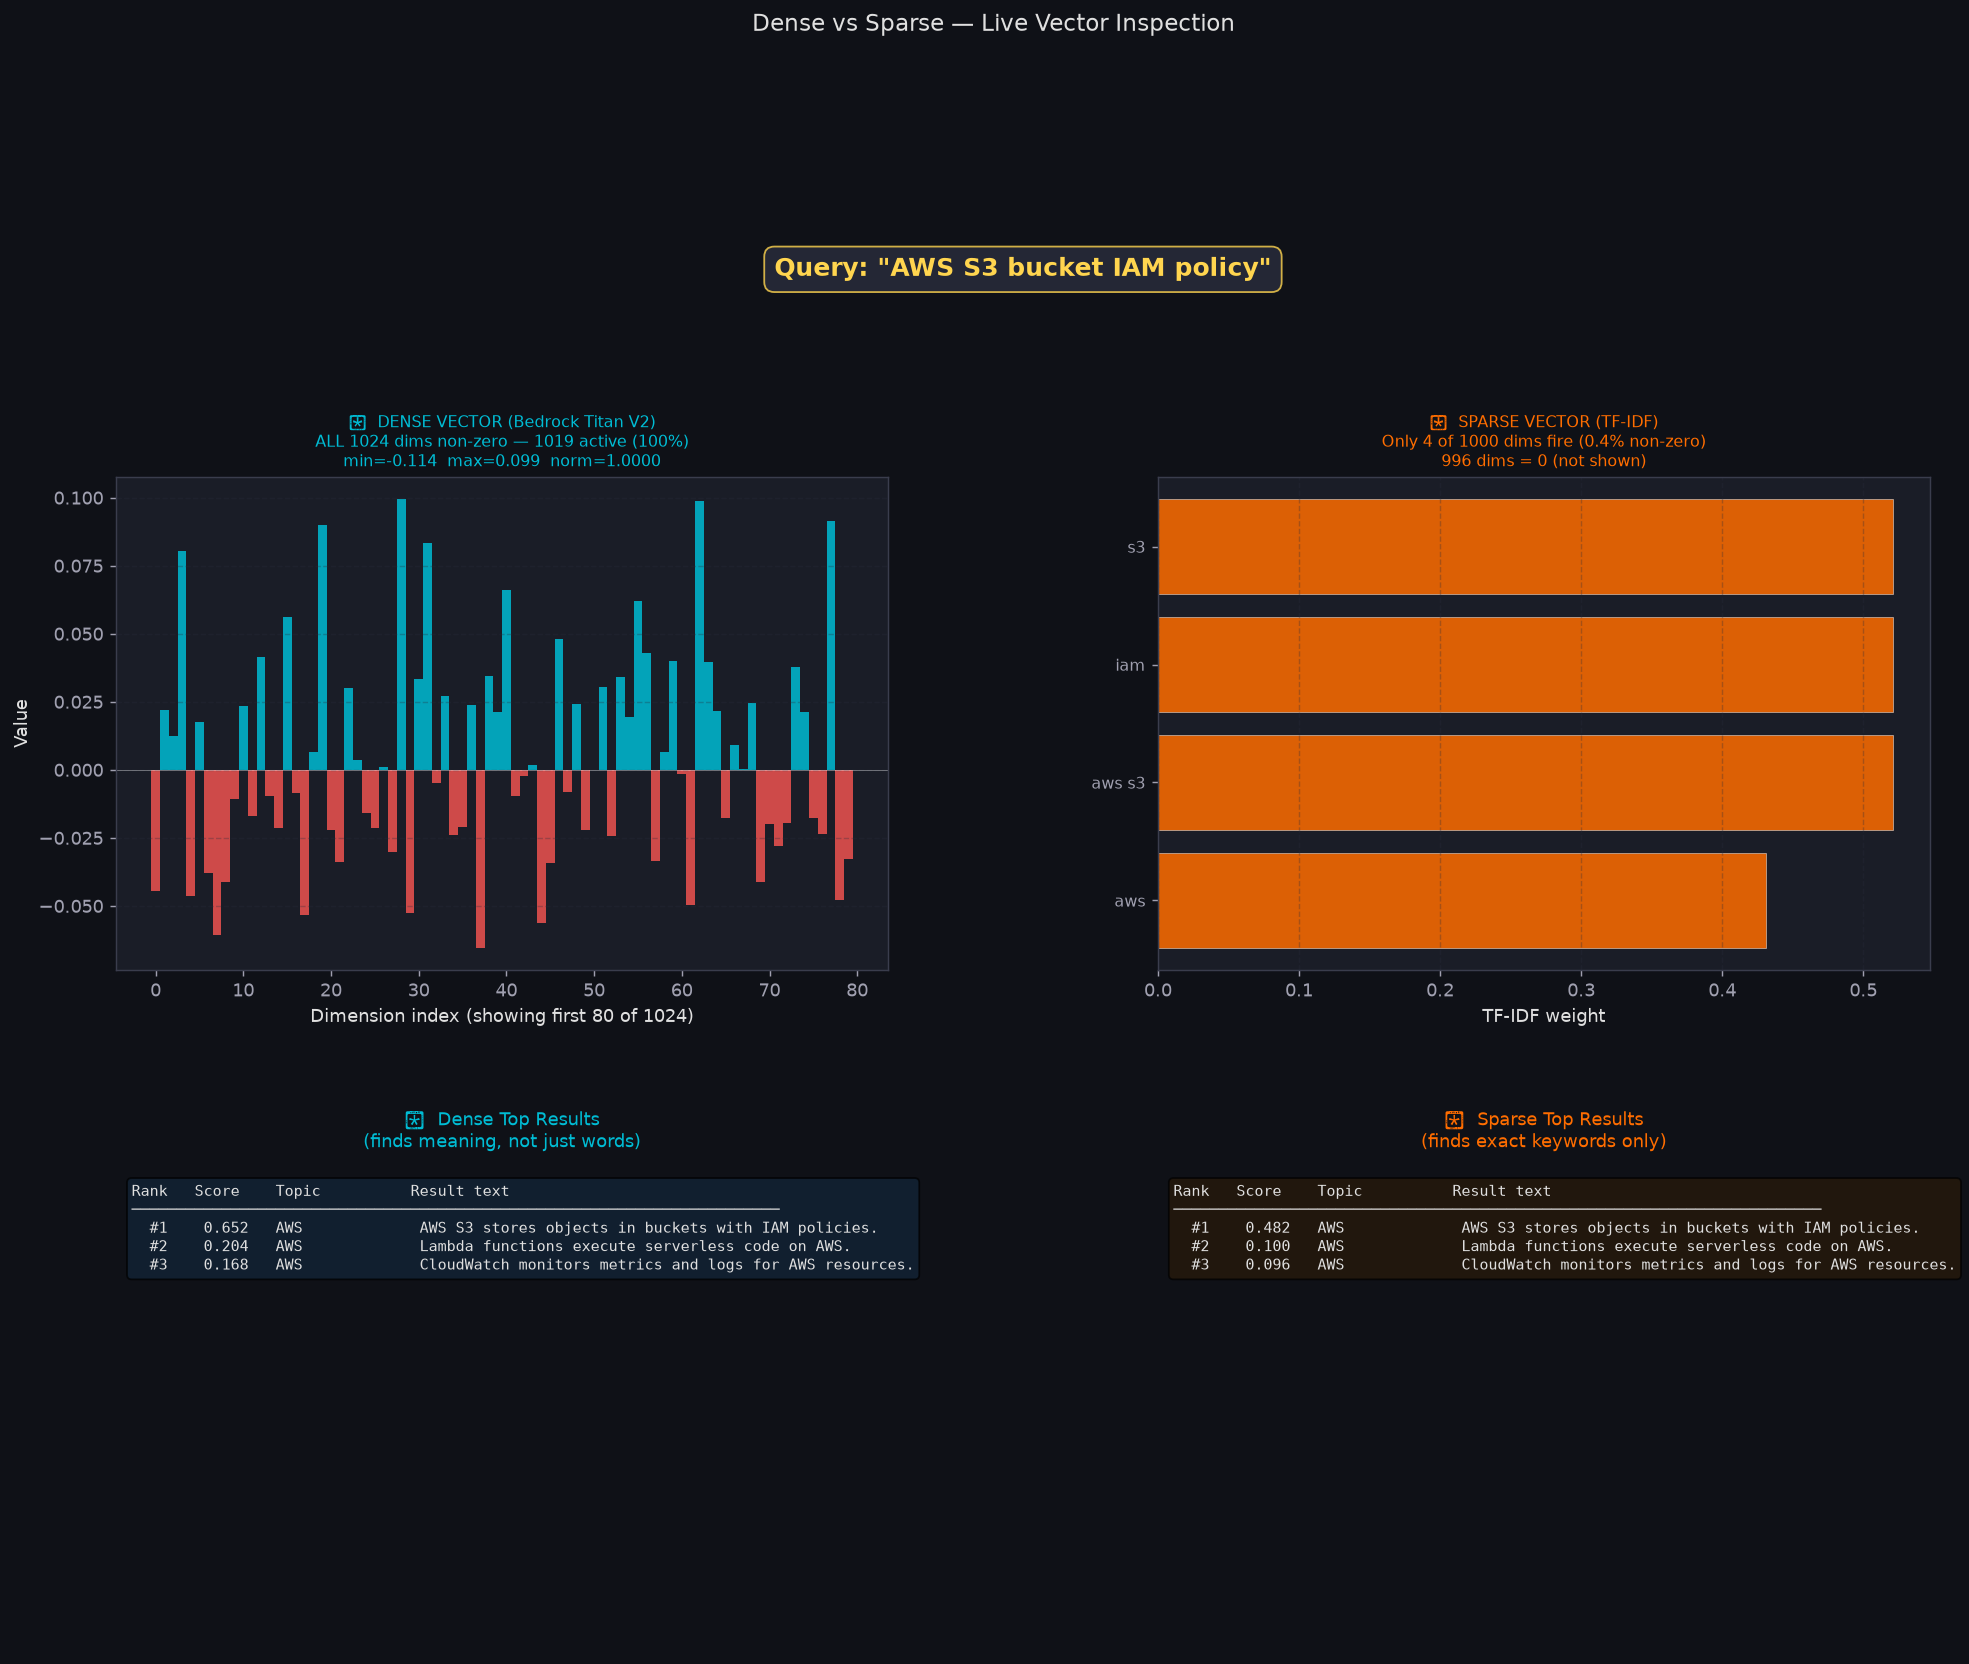


──────────────────────────────────────────────────────────────────────
Query        : "AWS S3 bucket IAM policy"
Dense vector : 1024 dims, ALL non-zero (1019 > 1e-4)
Sparse vector: 1000 dims, only 4 non-zero (0.4%)
Top sparse terms : aws s3(0.52), iam(0.52), s3(0.52)
Dense  #1 : "AWS S3 stores objects in buckets with IAM policies."  (score=0.652)
Sparse #1 : "AWS S3 stores objects in buckets with IAM policies."  (score=0.482)
Verdict      : ✅ AGREE — Dense→AWS  Sparse→AWS
──────────────────────────────────────────────────────────────────────



In [10]:
demo("AWS S3 bucket IAM policy")

### 7d — Exact keywords: Both work
> Exact words present in corpus → both methods succeed.

/tmp/ipykernel_313775/2401388543.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/participant/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/participant/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128999 (\N{LARGE ORANGE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


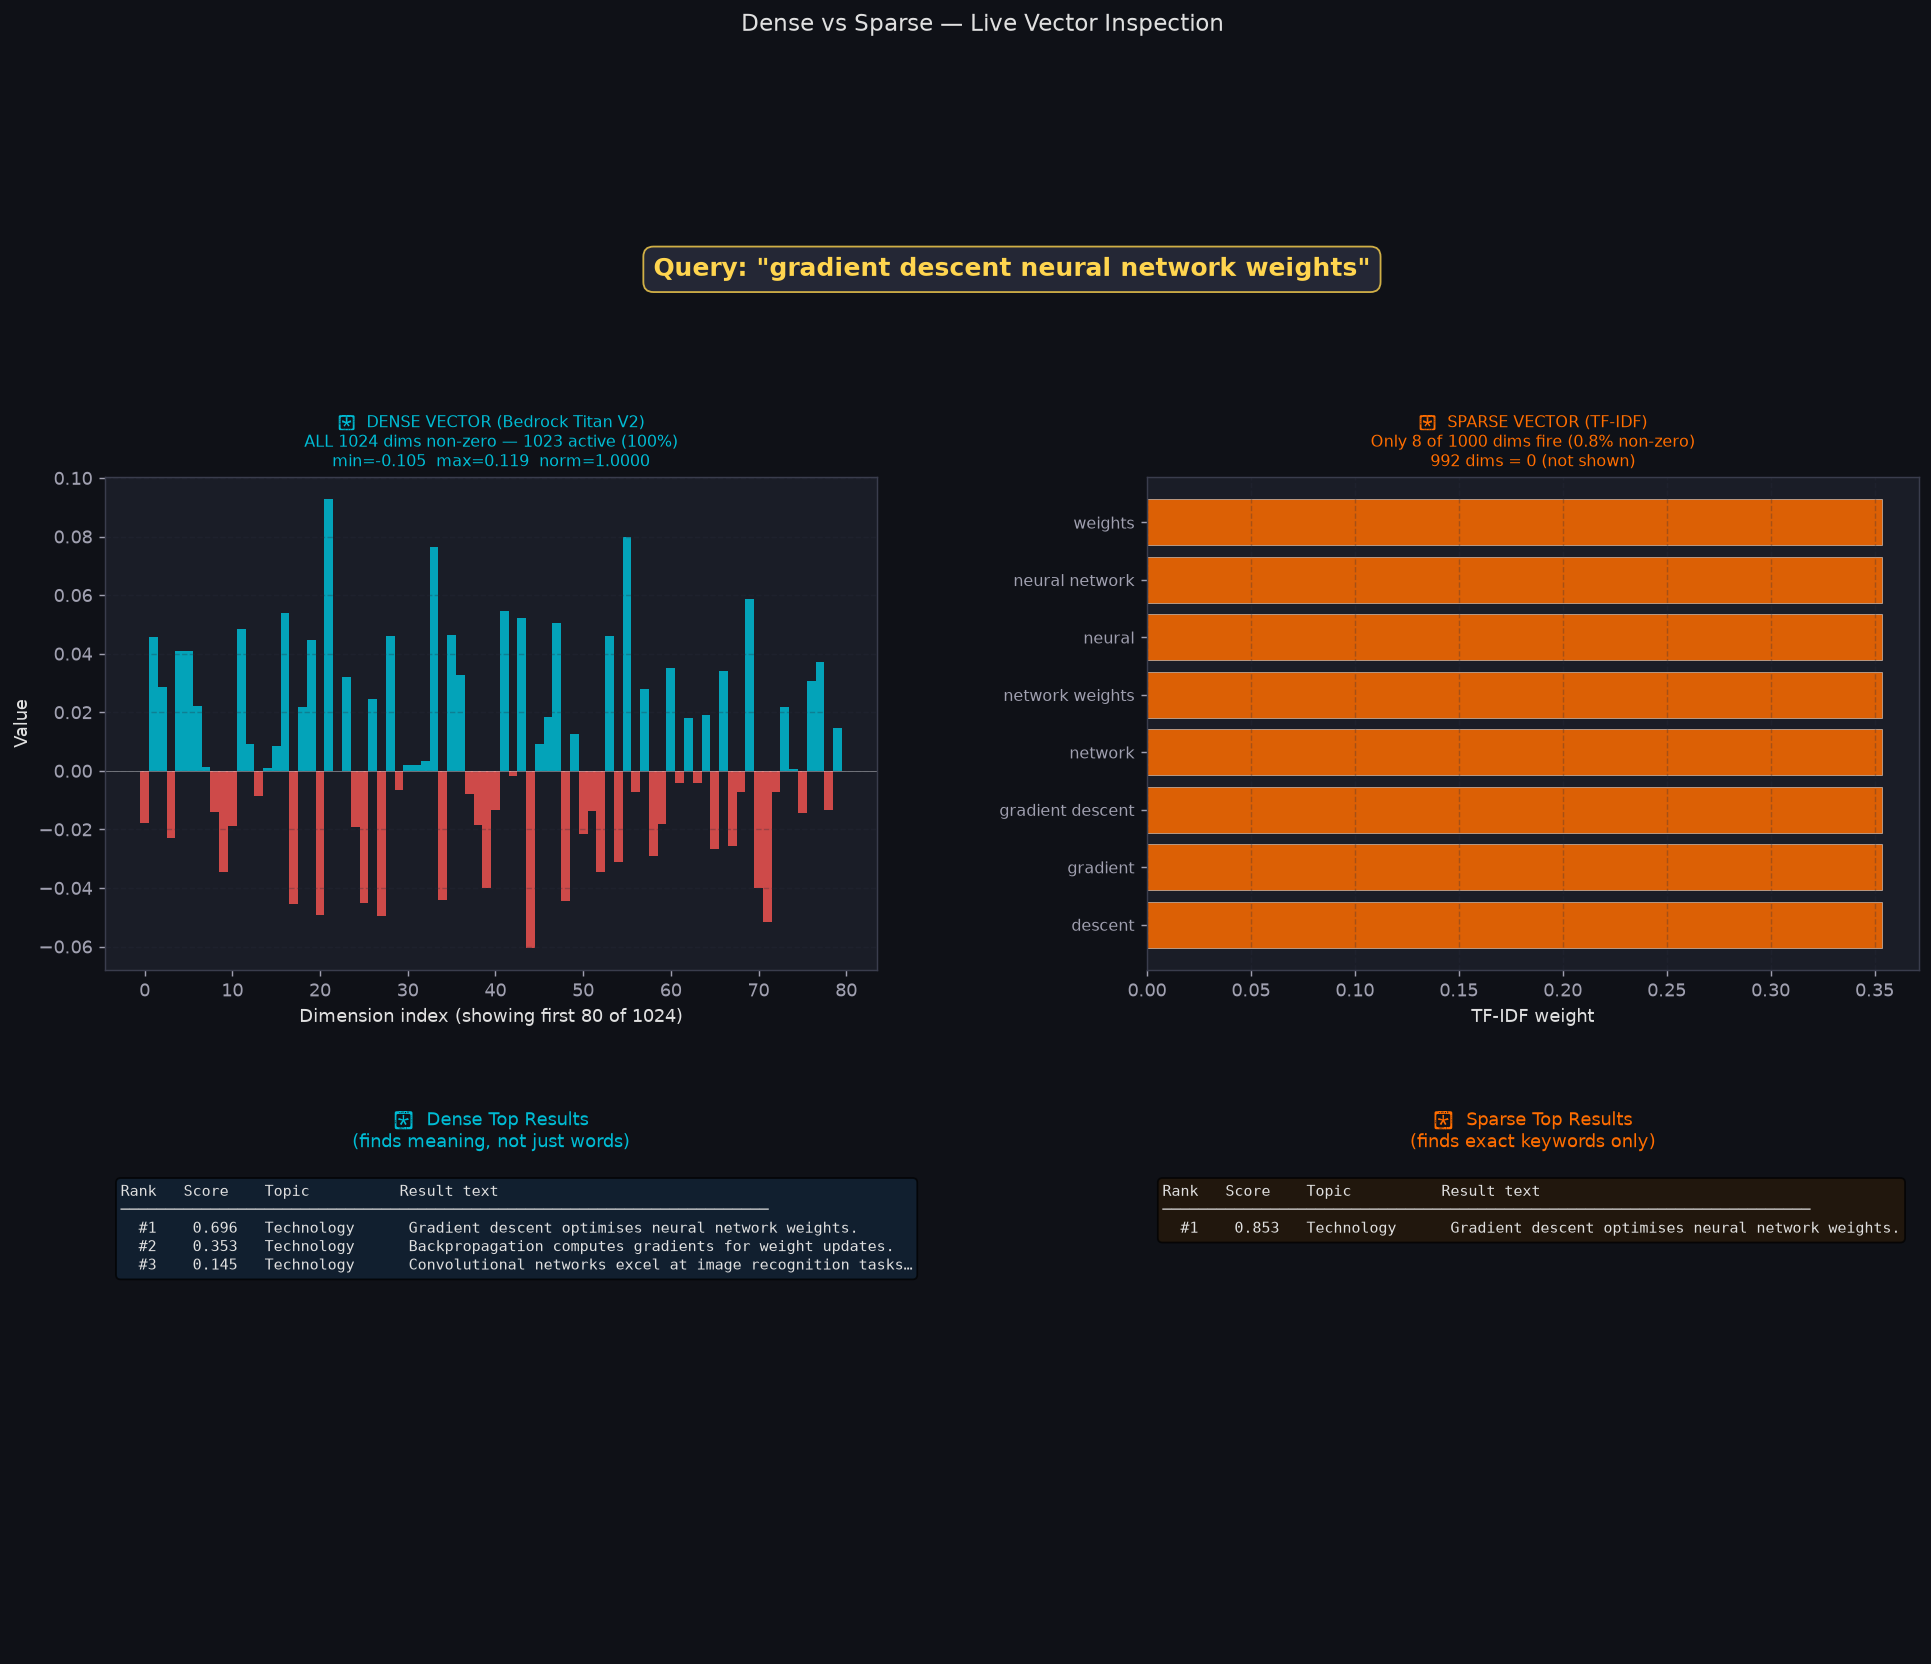


──────────────────────────────────────────────────────────────────────
Query        : "gradient descent neural network weights"
Dense vector : 1024 dims, ALL non-zero (1023 > 1e-4)
Sparse vector: 1000 dims, only 8 non-zero (0.8%)
Top sparse terms : descent(0.35), gradient(0.35), gradient descent(0.35)
Dense  #1 : "Gradient descent optimises neural network weights."  (score=0.696)
Sparse #1 : "Gradient descent optimises neural network weights."  (score=0.853)
Verdict      : ✅ AGREE — Dense→Technology  Sparse→Technology
──────────────────────────────────────────────────────────────────────



In [11]:
demo("gradient descent neural network weights")

### 7e — Total semantic gap: Dense bridges it, Sparse gives up
> No word overlap at all — dense uses geometry to bridge the gap.

/tmp/ipykernel_313775/2401388543.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/participant/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/participant/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128999 (\N{LARGE ORANGE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


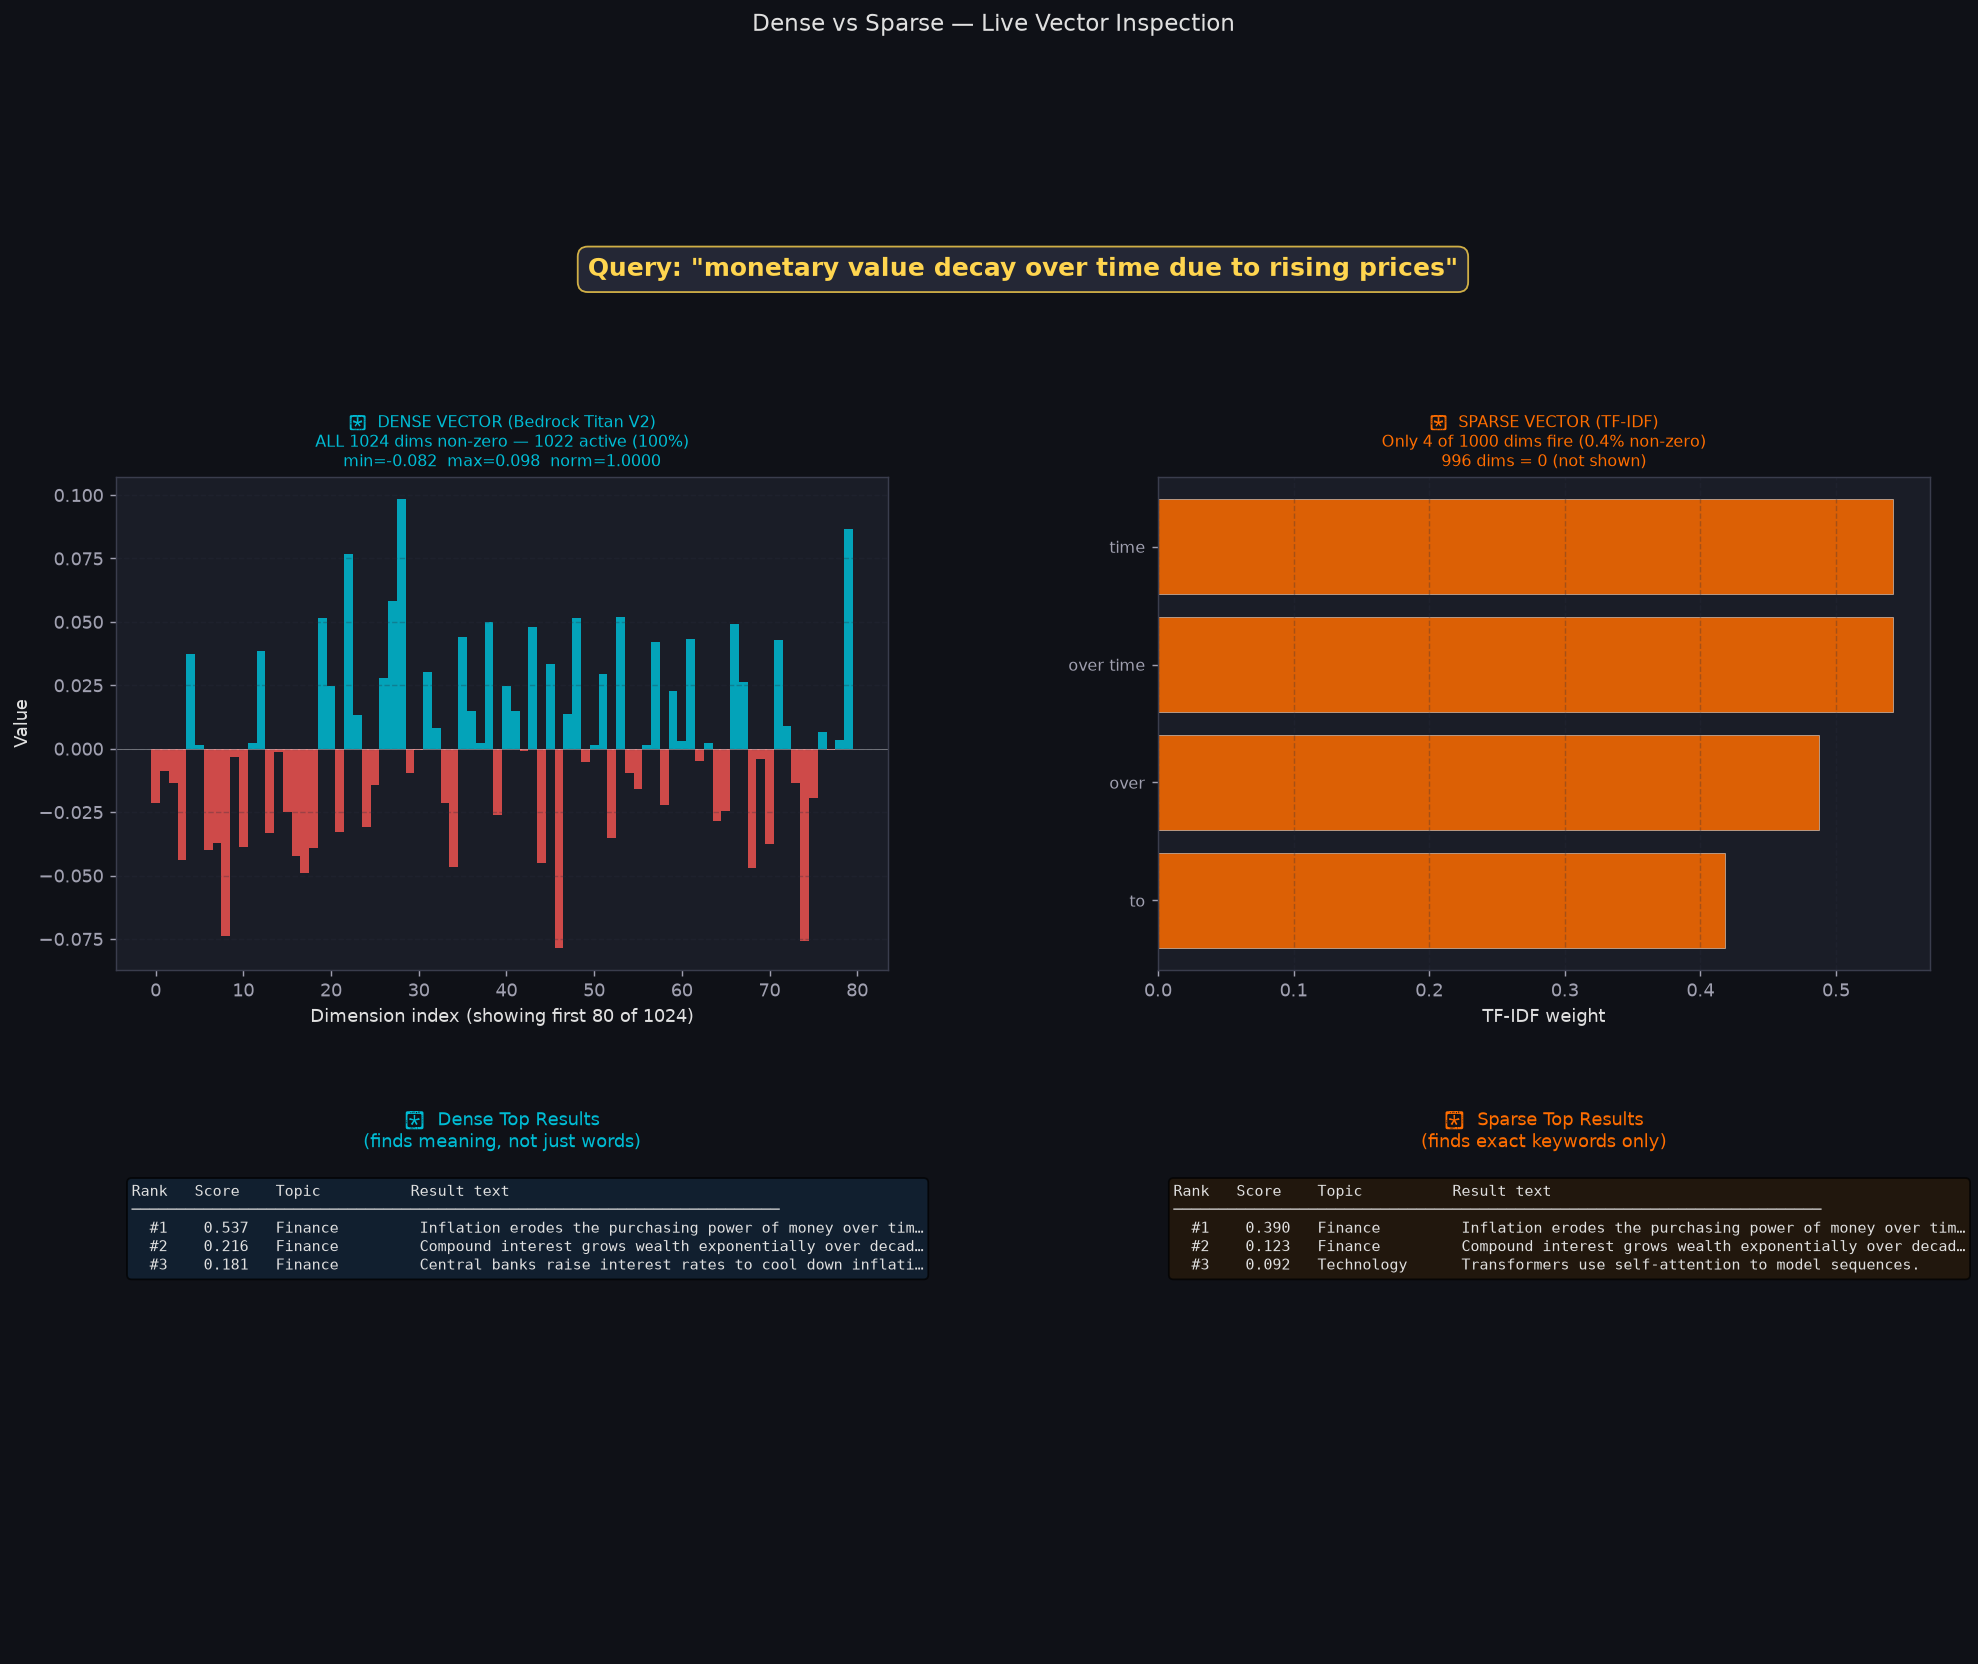


──────────────────────────────────────────────────────────────────────
Query        : "monetary value decay over time due to rising prices"
Dense vector : 1024 dims, ALL non-zero (1022 > 1e-4)
Sparse vector: 1000 dims, only 4 non-zero (0.4%)
Top sparse terms : over time(0.54), time(0.54), over(0.49)
Dense  #1 : "Inflation erodes the purchasing power of money over time."  (score=0.537)
Sparse #1 : "Inflation erodes the purchasing power of money over time."  (score=0.390)
Verdict      : ✅ AGREE — Dense→Finance  Sparse→Finance
──────────────────────────────────────────────────────────────────────



In [12]:
demo("monetary value decay over time due to rising prices")

### 7f — Your own query
> Change the string to anything you want to test.

/tmp/ipykernel_313775/2401388543.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/participant/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/participant/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128999 (\N{LARGE ORANGE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


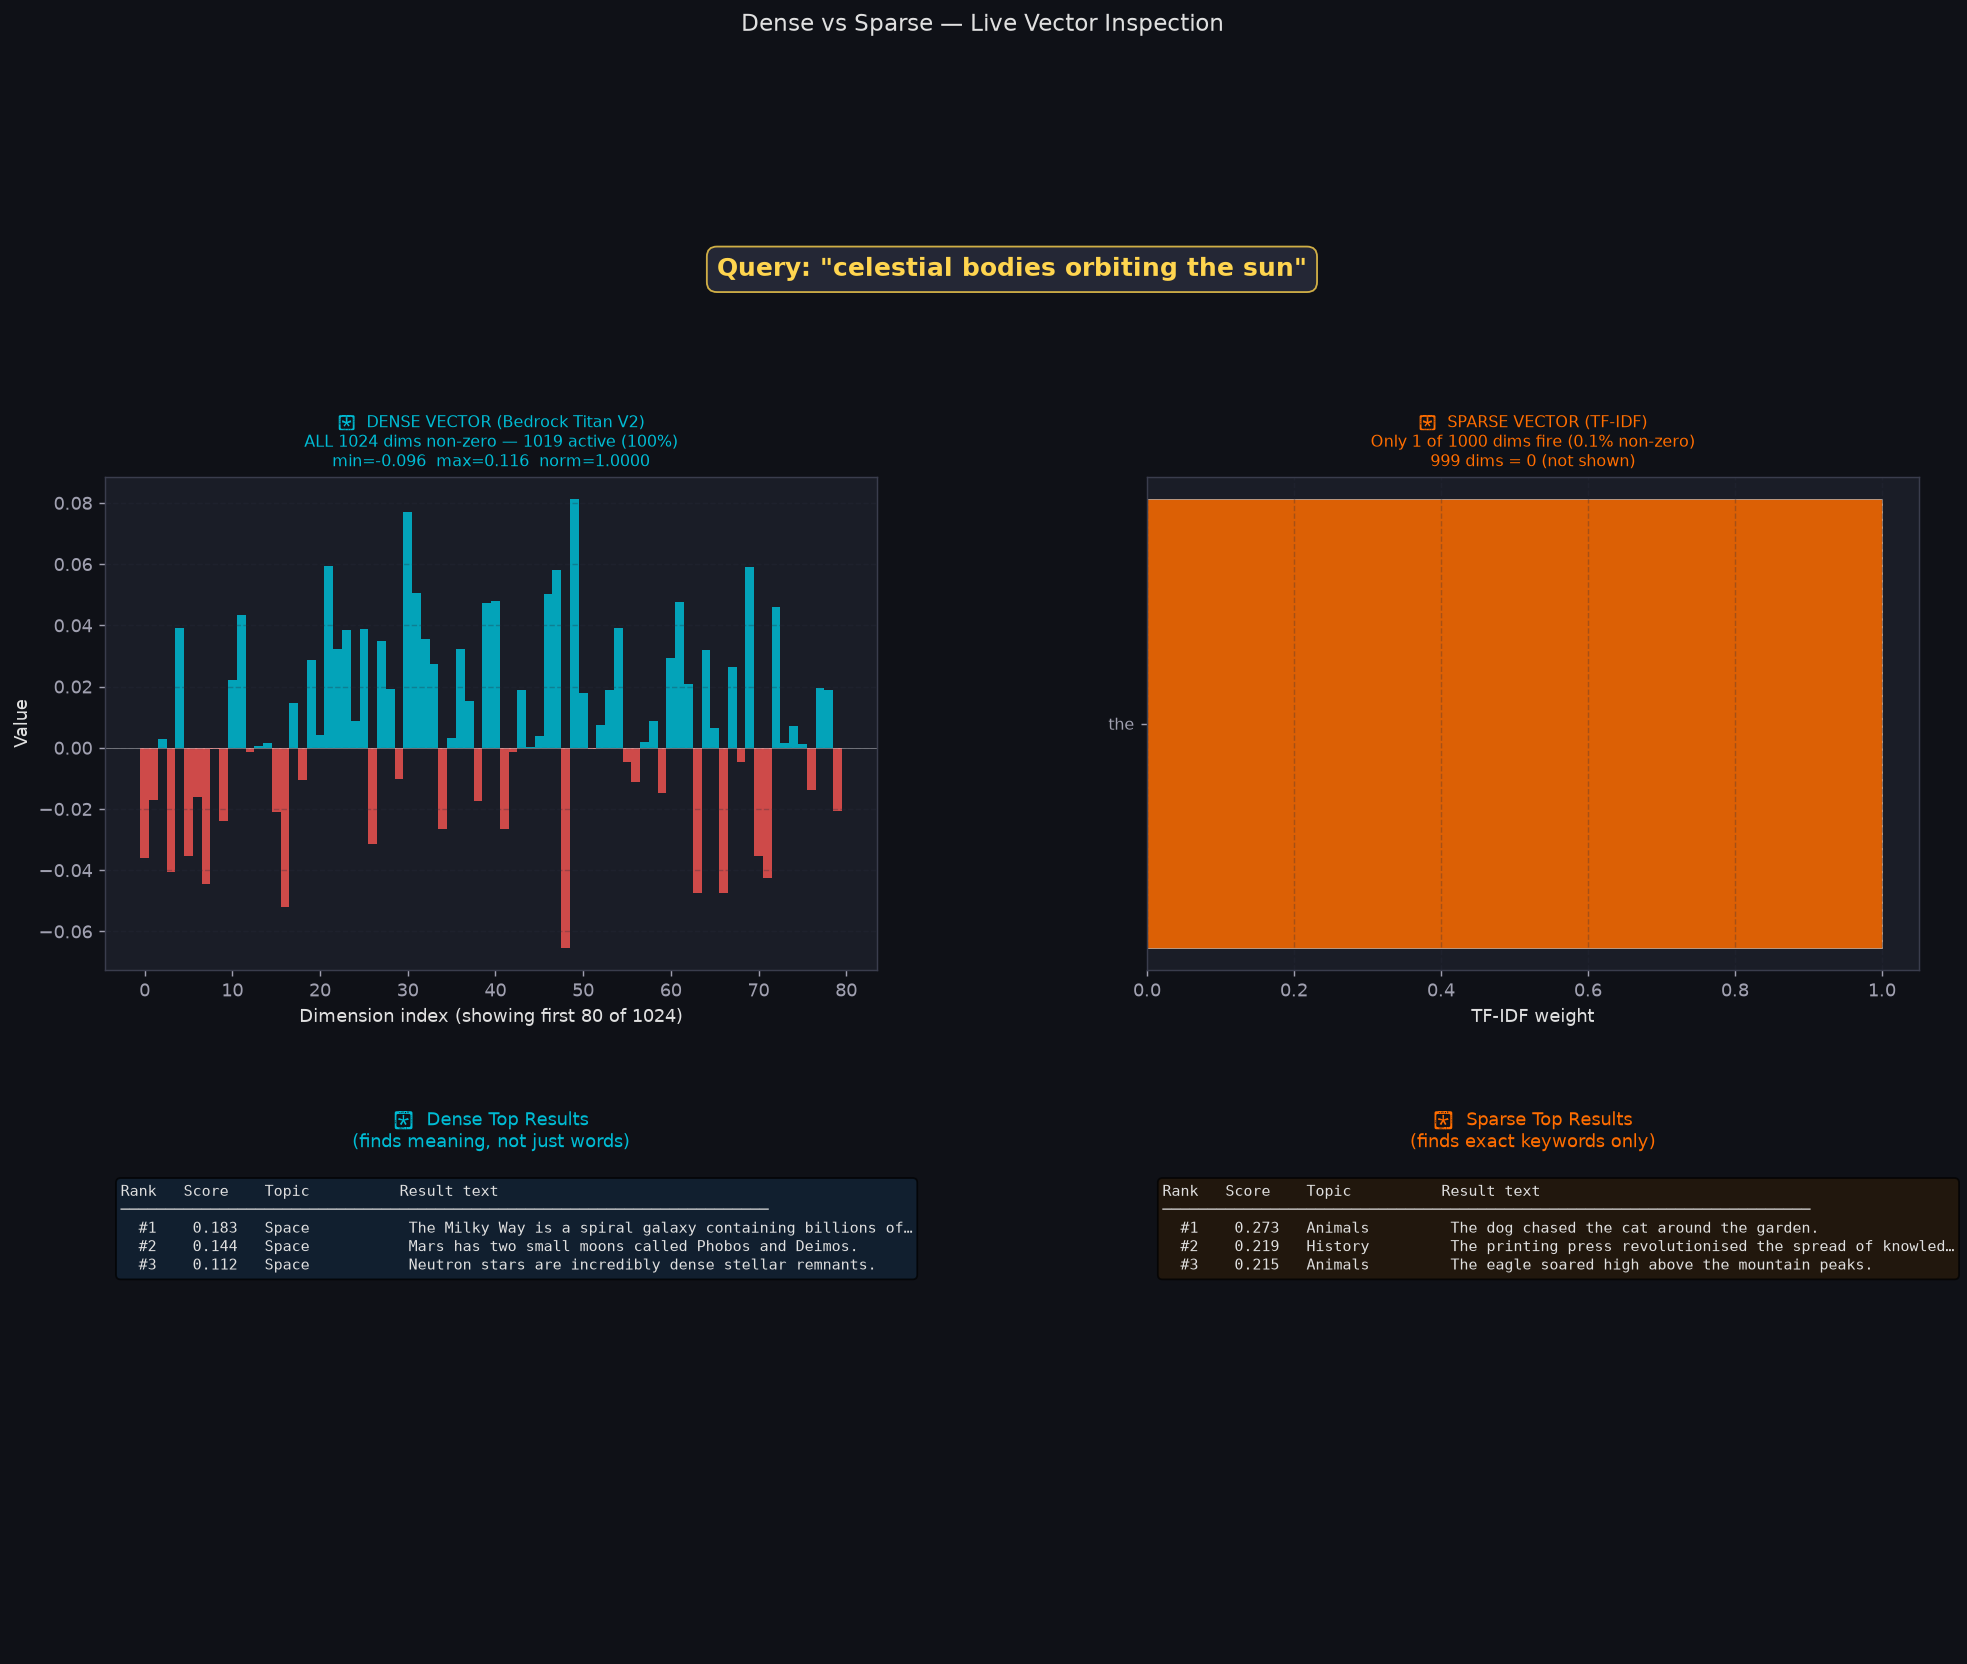


──────────────────────────────────────────────────────────────────────
Query        : "celestial bodies orbiting the sun"
Dense vector : 1024 dims, ALL non-zero (1019 > 1e-4)
Sparse vector: 1000 dims, only 1 non-zero (0.1%)
Top sparse terms : the(1.00)
Dense  #1 : "The Milky Way is a spiral galaxy containing billions of stars."  (score=0.183)
Sparse #1 : "The dog chased the cat around the garden."  (score=0.273)
Verdict      : ⚔️  DISAGREE — Dense→Space  Sparse→Animals
──────────────────────────────────────────────────────────────────────



In [13]:
demo("celestial bodies orbiting the sun")   # ← change this to anything

---
## NVIDIA Perspective — GPU-Accelerated Interactive Search

### Swap this demo's stack for NVIDIA GPU stack

```
This demo (CPU)                     NVIDIA GPU production
------------------------------------------------------------
Bedrock Titan V2 (API call)     ->  NIM llama-nemotron-embed-vl-1b-v2
TF-IDF sklearn (CPU)            ->  BM25 + cuVS backend
Qdrant :memory: (CPU HNSW)      ->  Qdrant + cuVS CAGRA (GPU graph ANN)
Single-query search             ->  Dynamic batching (10x latency gain)
```

### CAGRA for interactive demos

- *CAGRA was specifically engineered with online search in mind*
- *8x or more throughput improvement in persistent search mode*
- Outperforms HNSW even at batch size 10

The `demo(query)` function in this notebook would be **3-8x faster** on a GPU.

### cuVS Python API (drop-in replacement)

```python
# pip install cuvs
from cuvs.neighbors import cagra

# Build index on GPU (same dense_matrix from this notebook)
index_params = cagra.IndexParams(metric='cosine')
index = cagra.build(index_params, dense_matrix)

# Search on GPU
search_params = cagra.SearchParams(itopk_size=64)  # analogous to ef_search
distances, indices = cagra.search(search_params, index, query_vec, k=3)
```

### GPU-accelerated t-SNE (for the scatter plots in NB02)

```python
from cuml.manifold import TSNE   # RAPIDS cuML
tsne = TSNE(n_components=2, perplexity=5)
coords = tsne.fit_transform(dense_matrix)   # same call, GPU-accelerated
```

**Available in 6 languages:** Python / C++ / C / Rust / Java / Go

**References:**
- [cuVS documentation](https://docs.nvidia.com/cuvs/)
- [CAGRA persistent search](https://developer.nvidia.com/blog/optimizing-vector-search-for-indexing-and-real-time-retrieval-with-nvidia-cuvs/)
- [RAPIDS cuML (GPU t-SNE, UMAP)](https://rapids.ai)
- [NVIDIA NIM Embeddings](https://build.nvidia.com/explore/retrieval)


## Step 8 — Cleanup

In [14]:
qc.delete_collection(DCOLL)
qc.delete_collection(SCOLL)
print('Collections deleted.')

Collections deleted.


## Summary

| | Dense | Sparse |
|---|---|---|  
| **Dims** | 1024, ALL non-zero | 1000, ~1–3% non-zero |
| **Finds** | Meaning & synonyms | Exact words |
| **Fails on** | Product codes, proper nouns | Paraphrases, synonyms |
| **Speed** | Slower (API call) | Instant (local math) |
| **Best for** | RAG, Q&A, cross-lingual | SKUs, codes, keyword search |

**Next → `03_Hybrid_Search.ipynb`** — combine both and get the best of each.